In [1]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Yelp API Connection

Chicago was selected based on the results obtained during the customer exploratory data analysis (EDA), where it presented one of the largest customer populations and a high number of premium memberships. Therefore, restaurant information was collected for this city using the Yelp Fusion API

The objective of this notebook is to enrich the customer analysis by incorporating external restaurant information such as ratings, categories, price levels, and customer reviews

In [2]:
load_dotenv()

API_KEY = os.getenv("YELP_API_KEY")

headers = {
    "Authorization": f"Bearer {API_KEY}"
}

In [3]:
url = "https://api.yelp.com/v3/businesses/search"

params = {
    "location": "Chicago",
    "categories": "restaurants",
    "limit": 50
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

In [4]:
print(f"Response Status Code: {response.status_code}")

Response Status Code: 200


In [5]:
data = response.json()

print(data.keys())

dict_keys(['businesses', 'total', 'region'])


In [6]:
businesses = data["businesses"]

In [7]:
restaurants_df = pd.DataFrame(businesses)

In [8]:
restaurants_df.head()

,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,price,location,phone,display_phone,distance,business_hours,attributes
0,boE4Ahsssqic7o5wQLI04w,the-purple-pig-chicago,The Purple Pig,https://s3-media0.fl.yelpcdn.com/bphoto/8993TK...,False,https://www.yelp.com/biz/the-purple-pig-chicag...,9018,"[{'alias': 'tapasmallplates', 'title': 'Tapas/...",4.3,"{'latitude': 41.890694, 'longitude': -87.624782}","[pickup, delivery]",$$$,"{'address1': '444 N Michigan Ave', 'address2':...",+13124641744,(312) 464-1744,4672.658118,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
1,riT822EnU7y_5eCuJsd9sA,cindys-rooftop-chicago,Cindy's Rooftop,https://s3-media0.fl.yelpcdn.com/bphoto/XLdHyZ...,False,https://www.yelp.com/biz/cindys-rooftop-chicag...,2841,"[{'alias': 'newamerican', 'title': 'New Americ...",4.1,"{'latitude': 41.8816894031196, 'longitude': -8...","[restaurant_reservation, delivery]",$$$,"{'address1': '12 S Michigan Ave', 'address2': ...",+13127923502,(312) 792-3502,5091.190048,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
2,cKZNbMvoqJaUe7n6lf6i7w,wildberry-pancakes-and-cafe-chicago-2,Wildberry Pancakes and Cafe,https://s3-media0.fl.yelpcdn.com/bphoto/sYdVm-...,False,https://www.yelp.com/biz/wildberry-pancakes-an...,10345,"[{'alias': 'pancakes', 'title': 'Pancakes'}, {...",4.4,"{'latitude': 41.884721645455315, 'longitude': ...","[pickup, delivery]",$$,"{'address1': '130 E Randolph St', 'address2': ...",+13129389777,(312) 938-9777,5083.943291,"[{'open': [{'is_overnight': False, 'start': '0...","{'business_temp_closed': None, 'menu_url': 'ht..."
3,xoi7Cw7FoknAx5p880RtWQ,au-cheval-chicago,Au Cheval,https://s3-media0.fl.yelpcdn.com/bphoto/vKY9dR...,False,https://www.yelp.com/biz/au-cheval-chicago?adj...,9532,"[{'alias': 'bars', 'title': 'Bars'}, {'alias':...",4.4,"{'latitude': 41.88466, 'longitude': -87.647668}","[pickup, delivery]",$$,"{'address1': '800 W Randolph St', 'address2': ...",+13129294580,(312) 929-4580,3382.561987,"[{'open': [{'is_overnight': False, 'start': '1...","{'business_temp_closed': None, 'menu_url': 'ht..."
4,DXwSYgiXqIVNdO9dazel6w,pequods-pizza-chicago-3,Pequod's Pizza,https://s3-media0.fl.yelpcdn.com/bphoto/8QJUNb...,False,https://www.yelp.com/biz/pequods-pizza-chicago...,8928,"[{'alias': 'pizza', 'title': 'Pizza'}]",3.9,"{'latitude': 41.92187, 'longitude': -87.664486}","[delivery, pickup]",$$,"{'address1': '2207 N Clybourn Ave', 'address2'...",+17733271512,(773) 327-1512,2147.863733,"[{'open': [{'is_overnight': True, 'start': '11...","{'business_temp_closed': None, 'menu_url': 'ht..."


In [9]:
restaurants_df.columns

Index(['id', 'alias', 'name', 'image_url', 'is_closed', 'url', 'review_count',
       'categories', 'rating', 'coordinates', 'transactions', 'price',
       'location', 'phone', 'display_phone', 'distance', 'business_hours',
       'attributes'],
      dtype='str')

In [10]:
restaurants_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50 non-null     str    
 1   alias           50 non-null     str    
 2   name            50 non-null     str    
 3   image_url       50 non-null     str    
 4   is_closed       50 non-null     bool   
 5   url             50 non-null     str    
 6   review_count    50 non-null     int64  
 7   categories      50 non-null     object 
 8   rating          50 non-null     float64
 9   coordinates     50 non-null     object 
 10  transactions    50 non-null     object 
 11  price           47 non-null     str    
 12  location        50 non-null     object 
 13  phone           50 non-null     str    
 14  display_phone   50 non-null     str    
 15  distance        50 non-null     float64
 16  business_hours  50 non-null     object 
 17  attributes      50 non-null     object 
dtypes: 

In [11]:
restaurants_df.describe()

,review_count,rating,distance
count,50.000000,50.000000,50.000000
mean,1928.200000,4.330000,2900.477437
std,2721.254625,0.234955,1938.822757
min,142.000000,3.600000,196.305089
25%,474.000000,4.200000,1098.032169
50%,773.000000,4.350000,3028.912271
75%,1902.000000,4.475000,4175.110056
max,10345.000000,4.800000,7783.734827


In [12]:
restaurants_df.isnull().sum()

id                0
alias             0
name              0
image_url         0
is_closed         0
url               0
review_count      0
categories        0
rating            0
coordinates       0
transactions      0
price             3
location          0
phone             0
display_phone     0
distance          0
business_hours    0
attributes        0
dtype: int64

## Business Question 1

How are restaurant ratings distributed in Chicago?

Understanding the distribution of ratings allows us to evaluate the overall quality of restaurants available in the selected city. This information will later be compared with customer behavior and preferences to identify whether customers are surrounded by highly rated establishments.

In [13]:
restaurants_df["rating"].describe()

count    50.000000
mean      4.330000
std       0.234955
min       3.600000
25%       4.200000
50%       4.350000
75%       4.475000
max       4.800000
Name: rating, dtype: float64

In [14]:
restaurants_df["rating"].value_counts().sort_index()

rating
3.6     1
3.9     2
4.0     3
4.1     3
4.2     7
4.3     9
4.4    12
4.5     4
4.6     6
4.7     1
4.8     2
Name: count, dtype: int64

### Visualization

The following histogram illustrates the distribution of restaurant ratings in the selected sample. This visualization helps identify whether customer ratings are concentrated around specific values or spread across a wider range, providing a clearer understanding of the overall quality of restaurants in Chicago.

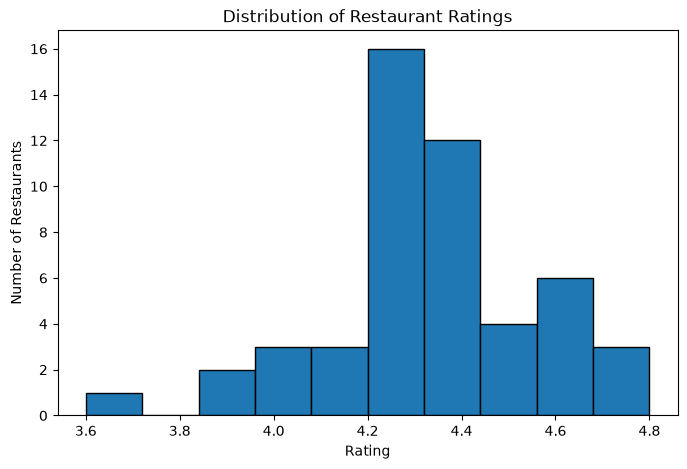

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    restaurants_df["rating"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()


### Insights

Most restaurant ratings are concentrated between **4.3 and 4.5 stars**, indicating that the majority of restaurants in the selected sample receive highly positive customer evaluations. Additionally, no restaurant has a rating below **3.9**, suggesting that the overall quality of restaurants in Chicago is consistently high.

### Business Impact
Since restaurant ratings present relatively little variation, future analyses should also consider variables such as review count and price level. Combining these variables provides a more comprehensive understanding of restaurant performance and customer preferences.

## Business Question 2

How are restaurants distributed across different price levels in Chicago?

Understanding the distribution of restaurant price levels allows us to characterize the affordability of the local restaurant market. This information will later be compared with customers' monthly restaurant spending to identify whether their spending habits align with the restaurant offerings available in Chicago.

In [16]:
restaurants_df["price"].value_counts(dropna=False)

price
$$      30
$$$     14
NaN      3
$$$$     2
$        1
Name: count, dtype: int64

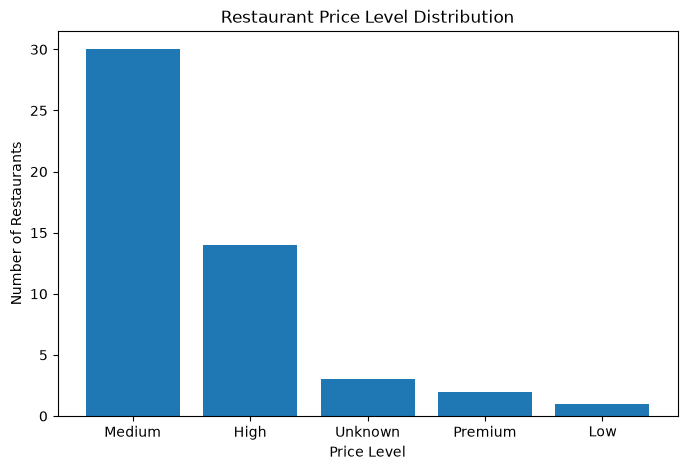

In [17]:
price_counts = (
    restaurants_df["price"]
    .fillna("Unknown")
    .replace({
        "$": "Low",
        "$$": "Medium",
        "$$$": "High",
        "$$$$": "Premium"
    })
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    price_counts.index,
    price_counts.values
)


plt.title("Restaurant Price Level Distribution")
plt.xlabel("Price Level")
plt.ylabel("Number of Restaurants")

plt.show()

### Insights

The price level distribution indicates that most restaurants in the selected sample belong to the **Medium** and **High** price categories. Only a small number of restaurants are classified as **Premium**, while a few businesses do not provide price information. Interestingly, no restaurants in the sample were classified in the **Low** price category.

### Business Impact

The predominance of medium- and high-priced restaurants suggests that customers in Chicago are primarily exposed to mid-range and premium dining options. This information will later be compared with customers' monthly restaurant spending and income levels to determine whether their spending behavior aligns with the pricing of restaurants available in the city.

In [18]:
restaurants_df["category_titles"] = restaurants_df["categories"].apply(
    lambda categories: ", ".join(
        category["title"] for category in categories
    )
)

restaurants_df[
    ["name", "category_titles"]
].head()

,name,category_titles
0,The Purple Pig,"Tapas/Small Plates, Mediterranean, New American"
1,Cindy's Rooftop,"New American, Seafood, Breakfast & Brunch"
2,Wildberry Pancakes and Cafe,"Pancakes, Waffles, Cafes"
3,Au Cheval,"Bars, Burgers, American"
4,Pequod's Pizza,Pizza


In [19]:
restaurants_df["category_list"] = restaurants_df["categories"].apply(
    lambda categories: [
        category["title"]
        for category in categories
    ]
)

In [20]:
category_df = restaurants_df.explode("category_list")
category_df["category_list"].value_counts()

category_list
New American          9
Cocktail Bars         7
Breakfast & Brunch    6
Italian               6
Bars                  5
                     ..
Mexican               1
African               1
Somali                1
Grocery               1
Delis                 1
Name: count, Length: 68, dtype: int64

In [21]:
category_df[
    ["name", "category_list"]
].head(10)

,name,category_list
0,The Purple Pig,Tapas/Small Plates
0,The Purple Pig,Mediterranean
0,The Purple Pig,New American
1,Cindy's Rooftop,New American
1,Cindy's Rooftop,Seafood
1,Cindy's Rooftop,Breakfast & Brunch
2,Wildberry Pancakes and Cafe,Pancakes
2,Wildberry Pancakes and Cafe,Waffles
2,Wildberry Pancakes and Cafe,Cafes
3,Au Cheval,Bars


In [22]:
category_counts = category_df["category_list"].value_counts().head(10)

## Business Question

What are the most common restaurant categories in Chicago?

Understanding the most common restaurant categories provides insight into the composition of the local restaurant market. This information can later be compared with customer food preferences to determine whether the available restaurant offerings align with customer demand.

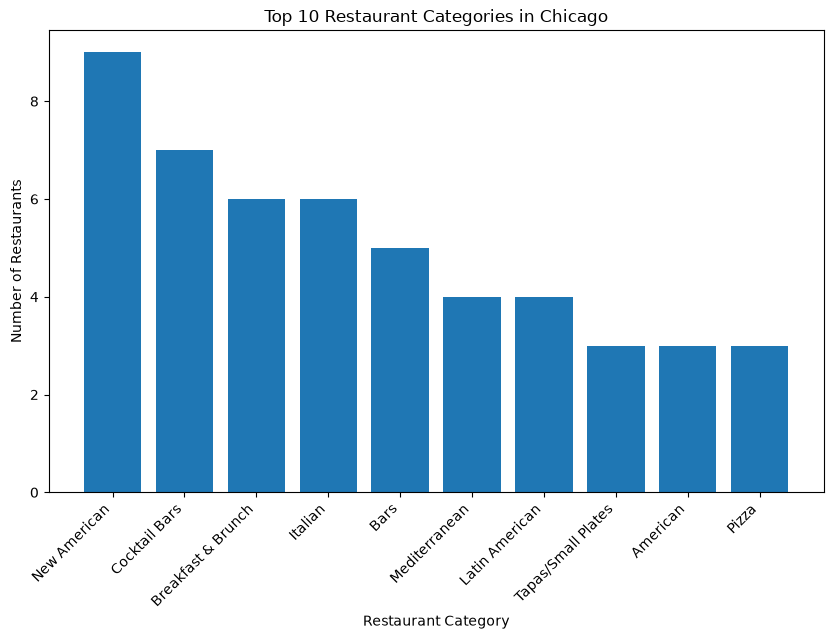

In [23]:
plt.figure(figsize=(10,6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Top 10 Restaurant Categories in Chicago")
plt.xlabel("Restaurant Category")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45, ha="right")

plt.show()

### Visualization

The following bar chart displays the ten most common restaurant categories among the restaurants retrieved from the Yelp API. This visualization helps identify which types of restaurants dominate the selected sample.

### Insights

The analysis shows that **New American** restaurants are the most common category within the selected sample, followed by **Breakfast & Brunch** and **Cocktail Bars**. Other categories such as **Italian**, **Steakhouses**, and **Seafood** are also represented but appear less frequently. This suggests that Chicago offers a diverse restaurant market while showing a stronger presence of modern American dining options.

### Business Impact

Identifying the most common restaurant categories provides valuable context for comparing restaurant availability with customer preferences from the customer dataset. In the next stage of the project, these categories can be related to customers' preferred cuisines and dining habits to evaluate whether the restaurant market aligns with consumer demand.

## Business Question

Which restaurants are the most popular based on the number of customer reviews?

The number of customer reviews is commonly used as an indicator of restaurant popularity and customer engagement. Analyzing review counts helps identify the businesses that receive the highest customer attention within the selected sample.

In [24]:
restaurants_df["review_count"].describe()

count       50.000000
mean      1928.200000
std       2721.254625
min        142.000000
25%        474.000000
50%        773.000000
75%       1902.000000
max      10345.000000
Name: review_count, dtype: float64

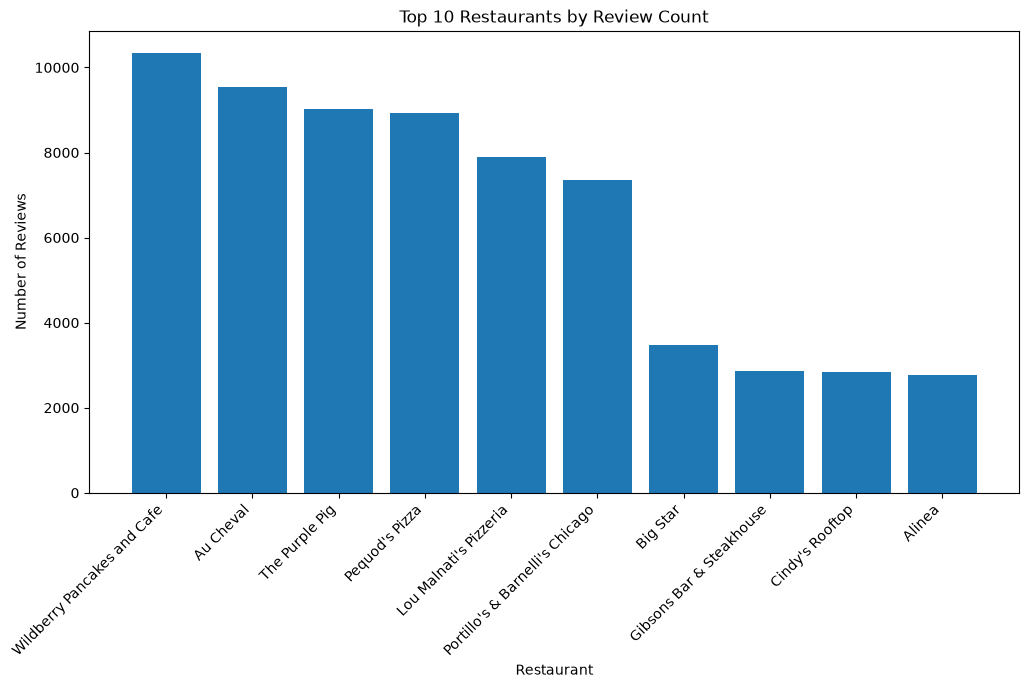

In [25]:
top_reviews = (
    restaurants_df
    .sort_values("review_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_reviews["name"],
    top_reviews["review_count"]
)

plt.title("Top 10 Restaurants by Review Count")
plt.xlabel("Restaurant")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45, ha="right")

plt.show()

### Visualization

The following bar chart displays the ten restaurants with the highest number of customer reviews retrieved from the Yelp API.

### Insights

The analysis shows that a small group of restaurants accumulates a significantly higher number of customer reviews than the rest of the sample. This suggests that customer attention is concentrated on a few highly recognized businesses, while most restaurants receive a more moderate level of customer interaction.

### Business Impact

Restaurants with a higher number of reviews generally have greater visibility and customer engagement. Combining review counts with customer ratings allows businesses to identify restaurants that are both popular and highly appreciated, providing useful information for future customer recommendation strategies.

## Business Question

Is there a relationship between restaurant ratings and the number of customer reviews?

This analysis explores whether restaurants with more customer reviews also tend to receive higher ratings. Understanding this relationship helps evaluate whether popularity is associated with customer satisfaction

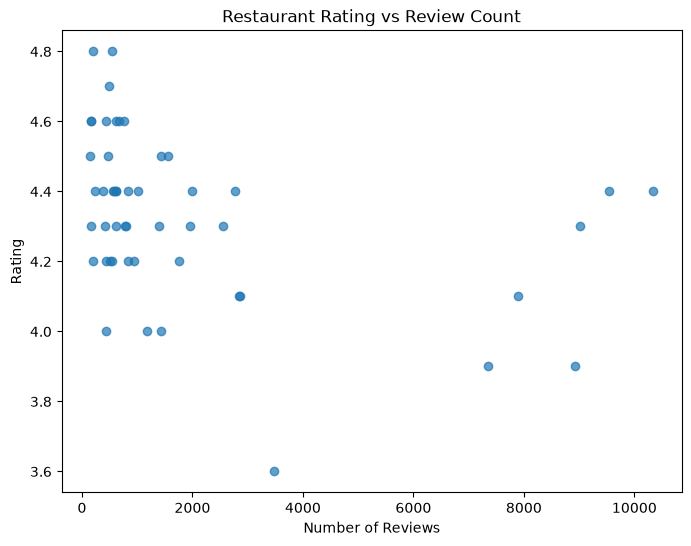

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    restaurants_df["review_count"],
    restaurants_df["rating"],
    alpha=0.7
)

plt.title("Restaurant Rating vs Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()

### Visualization

The following scatter plot compares restaurant ratings with the number of customer reviews for the selected restaurants in Chicago

### Insights

The scatter plot suggests that restaurants with a large number of customer reviews do not necessarily receive the highest ratings. While several highly reviewed restaurants maintain excellent ratings, there is no clear linear relationship between popularity and customer satisfaction within the selected sample

### Business Impact

Popularity and customer satisfaction represent different aspects of restaurant performance. Businesses seeking to recommend restaurants or analyze customer behavior should consider both review count and rating rather than relying on a single performance indicator.

# Integration with Customer Dataset

The Yelp API provides external information about restaurants in Chicago, including ratings, review counts, price levels, and restaurant categories. Although the Yelp dataset cannot be directly merged with the customer dataset because there is no common identifier, both datasets can be analyzed together to better understand customer behavior and the local restaurant market

The Yelp analysis revealed that:

- Most restaurants have ratings between **4.3 and 4.5**, indicating a generally high level of customer satisfaction.
- Medium and High price levels are the most common within the selected sample.
- New American, Breakfast & Brunch, and Cocktail Bars are among the most frequent restaurant categories.
- A small number of restaurants concentrate the highest number of customer reviews, suggesting higher popularity and customer engagement

These findings complement the customer dataset by providing additional context about the restaurant market in Chicago. Although both datasets cannot be directly merged because they do not share a common identifier, together they provide a more comprehensive understanding of customer behavior and the local restaurant environment

Y listo.

# Conclusion

Using the Yelp Fusion API allowed the incorporation of real-time restaurant information into the customer analysis. The external data provided valuable insights regarding restaurant quality, pricing, popularity, and categories, complementing the customer dataset and strengthening the overall business analysis for the selected city